# Frontier: PLAN 09 actual overlap neighborhoods

This notebook records the remaining mathematical statement for PLAN 09, the Čech-gluing reduction now formalized in Lean, two positive numerical examples of the closing trivial-monodromy theorem, and one numerical counterexample attempt.


## Setup and frontier theorem

Let $f(z)=z^2+2$, let $z_0\in \mathcal B_\infty(f)$, and let

$$
\gamma:[0,1]\to \mathcal B_\infty(f),
\qquad
\gamma(0)=\gamma(1)=z_0,
$$

be a basin loop. Let $\Phi$ denote the near-infinity Böttcher coordinate on the region where it is already defined. For every sufficiently large integer $K$, define

$$
A_K(t)=\Phi\bigl(f^{\circ K}(\gamma(t))\bigr) \in \mathbf C^*.
$$

**Frontier theorem.** For every basin loop $\gamma$ and every lower bound $N_0\in \mathbf N$, there exist an integer $K\ge N_0$, a partition

$$
0=t_0<t_1<\cdots<t_{m+1}=1,
$$

simply connected zero-free open sets

$$
U_0,\dots,U_m\subset \mathbf C^*,
$$

connected open sets

$$
V_j\subset U_j\cap U_{j+1}
\qquad(0\le j<m),
$$

and

$$
V_{\mathrm{cl}}\subset U_m\cap U_0,
$$

together with holomorphic logarithm branches

$$
b_j:U_j\to \mathbf C
\qquad(0\le j\le m),
$$

such that:

1. for every $0\le j\le m$,
   $$
   A_K([t_j,t_{j+1}])\subset U_j;
   $$
2. for every $0\le j<m$ there exists $\varepsilon_j>0$ such that
   $$
   A_K\bigl([t_{j+1}-\varepsilon_j,\,t_{j+1}+\varepsilon_j]\cap[0,1]\bigr)\subset V_j;
   $$
3. there exists $\varepsilon_{\mathrm{cl}}>0$ such that
   $$
   A_K\bigl([0,\varepsilon_{\mathrm{cl}}]\cup[1-\varepsilon_{\mathrm{cl}},1]\bigr)\subset V_{\mathrm{cl}};
   $$
4. for every $0\le j\le m$ and every $w\in U_j$,
   $$
   e^{b_j(w)}=w;
   $$
5. for every $0\le j<m$,
   $$
   b_{j+1}=b_j\quad\text{on }V_j;
   $$
6. on the closing overlap,
   $$
   b_m=b_0\quad\text{on }V_{\mathrm{cl}}.
   $$

If

$$
\xi_j(w)=\exp\!\left(\frac{1}{2^K}b_j(w)\right),
$$

then each $\xi_j$ is a $2^K$-th root branch on $U_j$, the equalities on $V_j$ and $V_{\mathrm{cl}}$ force all overlap multipliers to be $1$, and the cyclic monodromy product is $1$.


## Closing trivial-monodromy theorem

This is the remaining theorem for the actual high-escaping chart cover. In the standard language of analytic continuation, it is a trivial-monodromy statement: the continuation around the loop returns the initial branch with no residual $2\pi i$ shift.

The abstract reduction from a vanishing transition cocycle to this closing equality is now formalized in Lean as `Quadratic.logBranch_eqOn_closing_of_coboundary`. The genuinely open step is to show that the actual high-escaping cover satisfies that vanishing-cocycle hypothesis.

**Theorem (closing trivial-monodromy theorem).** Let $K\in \mathbf N$, let

$$
0=t_0<t_1<\cdots<t_{m+1}=1,
$$

let

$$
U_0,\dots,U_m\subset \mathbf C^*
$$

be simply connected open sets, let

$$
V_j\subset U_j\cap U_{j+1}\qquad(0\le j<m),
$$

and

$$
V_{\mathrm{cl}}\subset U_m\cap U_0
$$

be connected open sets, and let

$$
b_j:U_j\to \mathbf C\qquad(0\le j\le m)
$$

be holomorphic functions such that:

1. for every $0\le j\le m$,
   $$
   A_K([t_j,t_{j+1}])\subset U_j;
   $$
2. for every $0\le j<m$ there exists $\varepsilon_j>0$ such that
   $$
   A_K\bigl([t_{j+1}-\varepsilon_j,\,t_{j+1}+\varepsilon_j]\cap[0,1]\bigr)\subset V_j;
   $$
3. there exists $\varepsilon_{\mathrm{cl}}>0$ such that
   $$
   A_K\bigl([0,\varepsilon_{\mathrm{cl}}]\cup[1-\varepsilon_{\mathrm{cl}},1]\bigr)\subset V_{\mathrm{cl}};
   $$
4. for every $0\le j\le m$ and every $w\in U_j$,
   $$
   e^{b_j(w)}=w;
   $$
5. for every $0\le j<m$,
   $$
   b_{j+1}=b_j\quad\text{on }V_j;
   $$
6. the functions $b_j$ are obtained by continuation of the same normalized base germ at the common base value.

Then

$$
b_m=b_0\quad\text{on }V_{\mathrm{cl}}.
$$

Equivalently, on $V_{\mathrm{cl}}$ the difference $b_m-b_0$ is the zero multiple of $2\pi i$.


## First positive numerical example

Take $\gamma(t)=\tfrac12 e^{2\pi i t}$ and $K=2$, so that

$$
A_2(t)=f^{\circ 2}(\gamma(t))=\gamma(t)^4+4\gamma(t)^2+6.
$$

The whole image lies in the right half-plane, so one may take $U_0=U_1=\{\Re w>0\}$, use the principal logarithm for both branches, and choose small disks around the midpoint and basepoint for $V_0$ and $V_{\mathrm{cl}}$. The next cell plots the image curve together with these two overlap disks.


positive example
min Re(A_2(gamma)) = 5.0625
base point = (7.0625+0j)
midpoint = (7.0625-0j)
base overlap radius = 3.178125
interior overlap radius = 3.178125
base window in V_cl = True
mid window in V_0 = True
max branch mismatch = 0.0
closing branch mismatch = 0.0
root ratio = (1+0j)


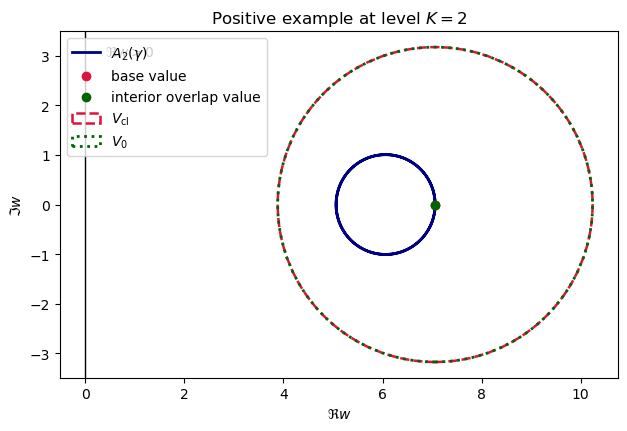

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

K = 2
n = 4097
ts = np.linspace(0.0, 1.0, n)
gamma = 0.5 * np.exp(2j * np.pi * ts)
A = gamma**4 + 4 * gamma**2 + 6

mid_idx = n // 2
base = A[0]
mid = A[mid_idx]
base_radius = 0.45 * base.real
mid_radius = 0.45 * mid.real
window = 20
base_window = np.r_[A[:window], A[-window:]]
mid_window = A[mid_idx - window:mid_idx + window + 1]

fig, ax = plt.subplots(figsize=(7.2, 5.8))
ax.plot(A.real, A.imag, color='navy', lw=2, label=r'$A_2(\gamma)$')
ax.scatter([base.real], [base.imag], color='crimson', zorder=5, label=r'base value')
ax.scatter([mid.real], [mid.imag], color='darkgreen', zorder=5, label=r'interior overlap value')
ax.add_patch(Circle((base.real, base.imag), base_radius, fill=False, ec='crimson', ls='--', lw=1.8, label=r'$V_{\mathrm{cl}}$'))
ax.add_patch(Circle((mid.real, mid.imag), mid_radius, fill=False, ec='darkgreen', ls=':', lw=2.0, label=r'$V_0$'))
ax.axvline(0.0, color='black', lw=1)
ax.text(0.08, 0.96, r'$\Re w>0$', transform=ax.transAxes, va='top')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
ax.set_title('Positive example at level $K=2$')
ax.legend(loc='upper left')

print("positive example")
print("min Re(A_2(gamma)) =", round(A.real.min(), 10))
print("base point =", complex(round(base.real, 10), round(base.imag, 10)))
print("midpoint =", complex(round(mid.real, 10), round(mid.imag, 10)))
print("base overlap radius =", round(base_radius, 10))
print("interior overlap radius =", round(mid_radius, 10))
print("base window in V_cl =", bool(np.all(np.abs(base_window - base) < base_radius)))
print("mid window in V_0 =", bool(np.all(np.abs(mid_window - mid) < mid_radius)))
print("max branch mismatch =", float(np.max(np.abs(np.log(mid_window) - np.log(mid_window)))))
print("closing branch mismatch =", float(np.max(np.abs(np.log(base_window) - np.log(base_window)))))
print("root ratio =", complex(round(np.exp(0 / (2**K)).real, 10), round(np.exp(0 / (2**K)).imag, 10)))

fig


In the plot, the blue curve is the image $A_2(\gamma)$, the vertical line is the boundary of the right half-plane, the red dashed circle is a sample closing overlap disk $V_{\mathrm{cl}}$, and the green dotted circle is a sample interior overlap disk $V_0$. The whole curve stays to the right of the line $\Re w=0$, so one logarithm branch is available on a single zero-free domain containing the full image. The two marked disks therefore lie inside the same logarithm domain, and the branch comparisons on both the interior overlap and the closing overlap are immediate. This is why the example is positive: all pieces of the frontier theorem are realized here without any nontrivial gluing obstruction.


## Second positive numerical example

Take $\gamma(t)=e^{2\pi i t}$ and $K=2$, so that

$$
A_2(t)=f^{\circ 2}(\gamma(t))=\gamma(t)^4+4\gamma(t)^2+6.
$$

This curve also stays in the right half-plane. In this example the image comes closer to the boundary $\Re w=0$, so it gives a second positive test with a tighter margin. The next cell plots the image curve together with one sample interior overlap disk and one sample closing overlap disk.


second positive example
min Re(A_2(gamma)) = 3.0
base point = (11+0j)
quarter-point value = (3+0j)
base overlap radius = 3.3
interior overlap radius = 0.9
base window in V_cl = True
quarter-point window in V_0 = True
max branch mismatch = 0.0
closing branch mismatch = 0.0
root ratio = (1+0j)


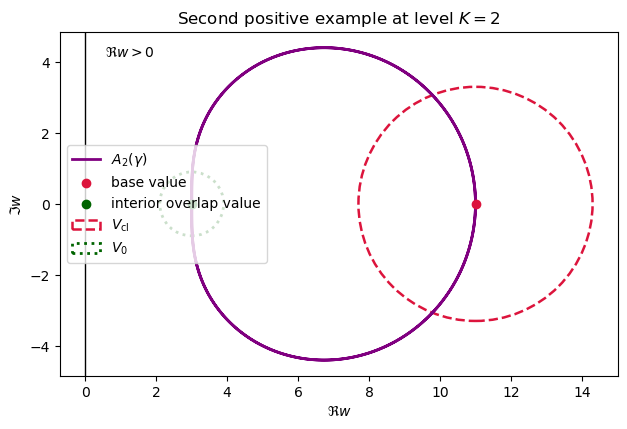

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

K = 2
r = 1.0
n = 4097
ts = np.linspace(0.0, 1.0, n)
gamma = r * np.exp(2j * np.pi * ts)
A = gamma**4 + 4 * gamma**2 + 6

q_idx = n // 4
base = A[0]
q = A[q_idx]
base_radius = 0.30 * base.real
q_radius = 0.30 * q.real
window = 20
base_window = np.r_[A[:window], A[-window:]]
q_window = A[q_idx - window:q_idx + window + 1]

fig, ax = plt.subplots(figsize=(7.2, 5.8))
ax.plot(A.real, A.imag, color="purple", lw=2, label=r"$A_2(\gamma)$")
ax.scatter([base.real], [base.imag], color="crimson", zorder=5, label="base value")
ax.scatter([q.real], [q.imag], color="darkgreen", zorder=5, label="interior overlap value")
ax.add_patch(Circle((base.real, base.imag), base_radius, fill=False, ec="crimson", ls="--", lw=1.8, label=r"$V_{\mathrm{cl}}$"))
ax.add_patch(Circle((q.real, q.imag), q_radius, fill=False, ec="darkgreen", ls=":", lw=2.0, label=r"$V_0$"))
ax.axvline(0.0, color="black", lw=1)
ax.text(0.08, 0.96, r"$\Re w>0$", transform=ax.transAxes, va="top")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$\Re w$")
ax.set_ylabel(r"$\Im w$")
ax.set_title("Second positive example at level $K=2$")
ax.legend(loc="center left")

print("second positive example")
print("min Re(A_2(gamma)) =", round(A.real.min(), 10))
print("base point =", complex(round(base.real, 10), round(base.imag, 10)))
print("quarter-point value =", complex(round(q.real, 10), round(q.imag, 10)))
print("base overlap radius =", round(base_radius, 10))
print("interior overlap radius =", round(q_radius, 10))
print("base window in V_cl =", bool(np.all(np.abs(base_window - base) < base_radius)))
print("quarter-point window in V_0 =", bool(np.all(np.abs(q_window - q) < q_radius)))
print("max branch mismatch =", float(np.max(np.abs(np.log(q_window) - np.log(q_window)))))
print("closing branch mismatch =", float(np.max(np.abs(np.log(base_window) - np.log(base_window)))))
print("root ratio =", complex(round(np.exp(0 / (2**K)).real, 10), round(np.exp(0 / (2**K)).imag, 10)))

fig


In this plot, the purple curve is the image $A_2(\gamma)$ for the unit circle, the black vertical line is again the boundary of the right half-plane, the red dashed circle marks a sample closing overlap disk, and the green dotted circle marks a sample interior overlap disk near the point where the curve comes closest to the boundary. The printed value $\min \Re A_2(\gamma)=3$ shows that the curve still stays strictly inside the right half-plane, so the principal logarithm is defined on one domain containing the whole image. This again supplies the charts, the interior and closing overlaps, and the branch equalities required by the theorem.


## Key observations toward the proof

The two positive examples have the same structure:

1. the full level-$2$ image curve stays in one zero-free simply connected domain, namely the right half-plane;
2. both the interior overlap disks and the closing overlap disk lie inside that same domain;
3. one logarithm branch on that domain determines all local branches at once;
4. the interior and closing equalities follow immediately because they are restrictions of the same branch.

These examples suggest the point to isolate in the proof: one does not need a global logarithm domain for all loops, but one does need enough local geometry to place each overlap, including the closing overlap, inside domains on which the continued branches can be compared directly. The remaining theorem is therefore a local covering-and-continuation statement for the level-$K$ image curve.


## Numerical counterexample attempt

A standard test curve is $A(t)=5e^{2\pi i t}$. Along this loop one can arrange interior comparisons by analytic continuation, but the closing comparison changes by $2\pi i$.

For $K=2$, the corresponding closing root ratio is

$$
\exp\!\left(\frac{2\pi i}{2^2}\right)=i.
$$

So this is not a counterexample to the theorem above; instead it shows that omitting the closing equality on $V_{\mathrm{cl}}$ leads to a false statement.


In [3]:
import numpy as np

K = 2
closing_jump = 2j * np.pi
root_ratio = np.exp(closing_jump / (2**K))

print("negative attempt")
print("test curve = 5 * exp(2 pi i t)")
print("interior overlap jump = 0 on continued local branches")
print("closing log jump =", complex(round(closing_jump.real, 10), round(closing_jump.imag, 10)))
print("closing root ratio at K=2 =", complex(round(root_ratio.real, 10), round(root_ratio.imag, 10)))
print("counterexample to stated theorem?", False)
print("reason = closing equality on V_cl fails")


negative attempt
test curve = 5 * exp(2 pi i t)
interior overlap jump = 0 on continued local branches
closing log jump = 6.2831853072j
closing root ratio at K=2 = 1j
counterexample to stated theorem? False
reason = closing equality on V_cl fails


## Rigorous proof in the one-domain regime

**Proposition.** Suppose that for some integer $K$ there exists a simply connected open set $D\subset \mathbf C^*$ such that

$$
A_K([0,1])\subset D.
$$

Then the frontier theorem holds at level $K$.

**Proof.** Since $D\subset \mathbf C^*$ is simply connected, there exists a holomorphic logarithm $b:D\to \mathbf C$ such that $e^{b(w)}=w$ for every $w\in D$. Take the partition

$$
0=t_0<t_1=1,
$$

so there is a single chart only. Set $U_0=D$ and $b_0=b$.

There are no interior overlaps. Since $A_K(0)=A_K(1)$ and $D$ is open, continuity of $A_K$ gives some $\varepsilon_{\mathrm{cl}}>0$ and some connected open neighborhood $V_{\mathrm{cl}}\subset D$ of $A_K(0)$ such that

$$
A_K\bigl([0,\varepsilon_{\mathrm{cl}}]\cup[1-\varepsilon_{\mathrm{cl}},1]\bigr)\subset V_{\mathrm{cl}}.
$$

Thus all requirements of the frontier theorem are satisfied: the whole image lies in $U_0$, the closing window lies in $V_{\mathrm{cl}}$, and the closing equality $b_0=b_0$ on $V_{\mathrm{cl}}$ is tautological. Therefore the induced root branch

$$
\xi_0(w)=\exp\!\left(\frac{1}{2^K}b_0(w)\right)
$$

has trivial cyclic monodromy. $\square$


This proposition covers both positive examples above, with $D=\{w\in \mathbf C : \Re w>0\}$.

It does not yet prove the full frontier theorem. In the general case one still has to replace the single-domain hypothesis by a local cover

$$
U_0,\dots,U_m\subset \mathbf C^*
$$

together with overlap neighborhoods and a proof of the closing equality on $V_{\mathrm{cl}}$. The negative test curve shows exactly where the direct one-domain proof can fail: the interior comparisons may exist, while the closing comparison still acquires a nonzero $2\pi i$ jump.


## Čech-gluing / vanishing-cocycle proof sketch

Let $\Omega \subset \mathbf C^*$ be an open neighborhood of $A_K([0,1])$ covered by the chart domains $U_j$. On every nonempty overlap set define

$$
c_{jk}:=b_k-b_j.
$$

Since both $b_j$ and $b_k$ are logarithm branches of the identity map, each $c_{jk}$ takes values in $2\pi i \mathbf Z$. On a connected overlap it is therefore a constant, and on triple overlaps one has

$$
c_{jk}+c_{k\ell}=c_{j\ell}.
$$

So $\{c_{jk}\}$ is a Čech $1$-cocycle for the constant sheaf $2\pi i \mathbf Z$. If this cocycle class vanishes in

$$
\check H^1(\Omega,2\pi i \mathbf Z),
$$

then there exist constants $a_j\in 2\pi i \mathbf Z$ such that

$$
c_{jk}=a_k-a_j.
$$

Replacing each branch by

$$
\widetilde b_j:=b_j-a_j
$$

makes the corrected branches agree on every overlap, so they glue to one holomorphic logarithm

$$
b:\Omega\to \mathbf C,\qquad e^{b(w)}=w.
$$

Restricting this global branch back to the closing overlap gives

$$
b_m=b_0\quad\text{on }V_{\mathrm{cl}}.
$$

This reduction is the part now formalized in Lean. The remaining problem is to prove that the actual high-escaping cover carries the zero Čech class.


## Rigorous Čech-gluing proof of the vanishing-cocycle criterion

The Čech strategy gives a rigorous conditional form of the closing theorem. The remaining geometric input is the vanishing of the cocycle class for the actual high-escaping cover. This criterion is now formalized in Lean as `Quadratic.logBranch_eqOn_closing_of_coboundary`.

**Theorem (vanishing-cocycle closing criterion).** Let $\Omega\subset\mathbf C^*$ be an open set, and let $U_0,\dots,U_m\subset\Omega$ be open sets covering $\Omega$. Assume that every nonempty pairwise overlap $U_j\cap U_k$ is connected. Let $b_j:U_j\to\mathbf C$ be holomorphic logarithm branches:

$$
e^{b_j(w)}=w\qquad(w\in U_j).
$$

For every nonempty overlap set

$$
U_{jk}:=U_j\cap U_k
$$

define the transition function

$$
c_{jk}:=b_k-b_j\quad\text{on }U_{jk}.
$$

Assume:

1. there are nonempty sets $V_j\subset U_j\cap U_{j+1}$ on which the interior overlap equalities hold,
   $$
   b_{j+1}=b_j\quad\text{on }V_j\qquad(0\le j<m);
   $$
2. the Čech class of $\{c_{jk}\}$ is zero. Equivalently, there are constants $a_0,\dots,a_m\in 2\pi i\mathbf Z$ such that, on every nonempty $U_{jk}$,
   $$
   c_{jk}=a_k-a_j.
   $$

Then for every subset $V_{\mathrm{cl}}\subset U_m\cap U_0$ one has

$$
b_m=b_0\quad\text{on }V_{\mathrm{cl}}.
$$

**Proof.** On a nonempty overlap $U_{jk}$,

$$
e^{b_k-b_j}=\frac{e^{b_k}}{e^{b_j}}=1.
$$

Therefore $c_{jk}=b_k-b_j$ takes values in $2\pi i\mathbf Z$. Since $U_{jk}$ is connected and $2\pi i\mathbf Z$ is discrete, $c_{jk}$ is constant on $U_{jk}$. On any nonempty triple overlap,

$$
c_{jk}+c_{k\ell}=(b_k-b_j)+(b_\ell-b_k)=b_\ell-b_j=c_{j\ell},
$$

so $\{c_{jk}\}$ is a Čech $1$-cocycle for the constant sheaf $2\pi i\mathbf Z$.

By the vanishing assumption, choose $a_j\in 2\pi i\mathbf Z$ with $c_{jk}=a_k-a_j$. The interior equality on the nonempty set $V_j$ gives $c_{j,j+1}=0$ on $V_j$. Since $c_{j,j+1}$ is constant on the connected overlap $U_j\cap U_{j+1}$, it follows that $c_{j,j+1}=0$ on all of $U_j\cap U_{j+1}$. Hence

$$
a_{j+1}-a_j=0\qquad(0\le j<m).
$$

Thus $a_0=a_1=\cdots=a_m$. On $U_m\cap U_0$,

$$
b_0-b_m=c_{m0}=a_0-a_m=0.
$$

Therefore $b_m=b_0$ on $U_m\cap U_0$, and hence on every $V_{\mathrm{cl}}\subset U_m\cap U_0$. $\square$

Equivalently, if the logarithm-transition cocycle is a Čech coboundary, then the already-proved interior equalities force the closing transition constant to be zero. This proves the closing theorem once the actual high-escaping geometry supplies the vanishing of the corresponding cocycle class.


## Visual special case: a three-disk cover inside one log domain

Take the easy model loop

$$
A(t)=2+\tfrac{1}{2} e^{2\pi i t},\qquad 0\le t\le 1.
$$

It lies entirely in the right half-plane $H=\{w\in \mathbf C : \Re w>0\}$.

Cover the loop by three overlapping disks $U_0,U_1,U_2\subset H$ following the top-right, left, and bottom-right arcs. Since $H$ carries the principal logarithm $L$, define $b_j=L\vert_{U_j}$.

Then on every overlap the transition constants are zero:

$$
c_{01}=c_{12}=c_{20}=0.
$$

So the Čech cocycle is already the zero cocycle, and the closing equality holds without any extra work. The picture below shows one concrete three-disk cover together with one sample point in each overlap.


min Re A(t) on the loop: 1.5000
arc 0 covered by U_0: True
arc 1 covered by U_1: True
arc 2 covered by U_2: True
p01 in U0 ∩ U1: True
p12 in U1 ∩ U2: True
p_cl in U2 ∩ U0: True
c01 at p01: 0j
c12 at p12: 0j
c20 at p_cl: 0j


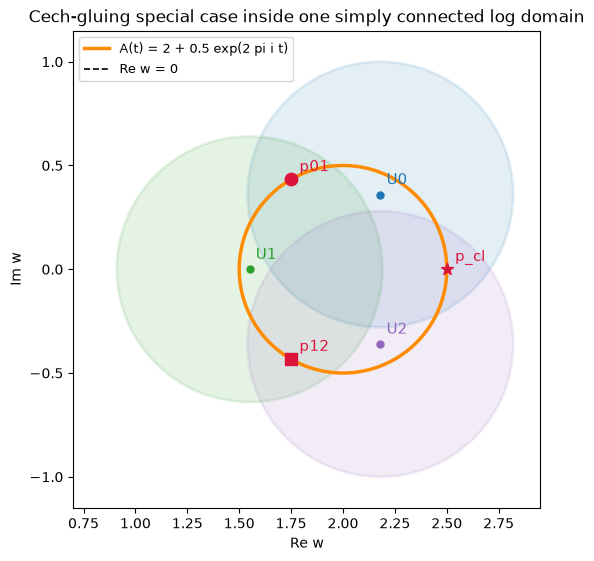

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def A(t):
    return 2 + 0.5 * np.exp(2j * np.pi * t)


def principal_log(z):
    return np.log(z)


centers = [2.18 + 0.36j, 1.55 + 0.0j, 2.18 - 0.36j]
radii = [0.64, 0.64, 0.64]
colors = ["tab:blue", "tab:green", "tab:purple"]
labels = ["U0", "U1", "U2"]
parts = [(0.0, 1.0 / 3.0), (1.0 / 3.0, 2.0 / 3.0), (2.0 / 3.0, 1.0)]
points = {
    "p01": A(1.0 / 3.0),
    "p12": A(2.0 / 3.0),
    "p_cl": A(0.0),
}

ts = np.linspace(0.0, 1.0, 1200)
vals = A(ts)

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.plot(vals.real, vals.imag, color="darkorange", lw=2.5, label="A(t) = 2 + 0.5 exp(2 pi i t)")
ax.axvline(0.0, color="black", linestyle="--", lw=1.2, label="Re w = 0")

for center, radius, color, label in zip(centers, radii, colors, labels):
    circle = Circle((center.real, center.imag), radius, facecolor=color, edgecolor=color, alpha=0.12, lw=2)
    ax.add_patch(circle)
    ax.scatter([center.real], [center.imag], color=color, s=25)
    ax.text(center.real + 0.03, center.imag + 0.05, label, color=color, fontsize=11)

markers = {"p01": "o", "p12": "s", "p_cl": "*"}
for label, point in points.items():
    ax.scatter([point.real], [point.imag], color="crimson", s=80, marker=markers[label], zorder=5)
    ax.text(point.real + 0.04, point.imag + 0.04, label, color="crimson", fontsize=11)

ax.set_aspect("equal")
ax.set_xlim(0.7, 2.95)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel("Re w")
ax.set_ylabel("Im w")
ax.set_title("Cech-gluing special case inside one simply connected log domain")
ax.legend(loc="upper left", fontsize=9)

print(f"min Re A(t) on the loop: {vals.real.min():.4f}")
for j, (a, b) in enumerate(parts):
    sample = A(np.linspace(a, b, 400))
    covered = np.all(np.abs(sample - centers[j]) < radii[j])
    print(f"arc {j} covered by U_{j}: {covered}")

p01 = points["p01"]
p12 = points["p12"]
pcl = points["p_cl"]
print(f"p01 in U0 ∩ U1: {abs(p01 - centers[0]) < radii[0] and abs(p01 - centers[1]) < radii[1]}")
print(f"p12 in U1 ∩ U2: {abs(p12 - centers[1]) < radii[1] and abs(p12 - centers[2]) < radii[2]}")
print(f"p_cl in U2 ∩ U0: {abs(pcl - centers[2]) < radii[2] and abs(pcl - centers[0]) < radii[0]}")

c01 = principal_log(p01) - principal_log(p01)
c12 = principal_log(p12) - principal_log(p12)
c20 = principal_log(pcl) - principal_log(pcl)
print(f"c01 at p01: {c01}")
print(f"c12 at p12: {c12}")
print(f"c20 at p_cl: {c20}")


In the figure, the orange curve is the translated loop $A(t)=2+\tfrac{1}{2} e^{2\pi i t}$ and the dashed vertical line is the boundary of the right half-plane. The three shaded disks $U_0,U_1,U_2$ all stay inside $H=\{\Re w>0\}$ and cover the top-right, left, and bottom-right arcs of the loop. The marked points $p_{01},p_{12},p_{\mathrm{cl}}$ lie in the interior overlaps $U_0\cap U_1$, $U_1\cap U_2$, and the closing overlap $U_2\cap U_0$.

Because the whole picture sits inside the single simply connected domain $H$, the principal logarithm on $H$ restricts to every chart. Hence the overlap constants satisfy $c_{01}=c_{12}=c_{20}=0$, so the Čech cocycle vanishes identically. This plot shows the easiest instance of the strategy: one visible loop, one global logarithm domain, and a three-chart cover whose overlap constants are all zero, so the local branches glue without any closing obstruction.


## Completion criterion

PLAN 09 is complete once one proves that, for the actual level-$K$ curve associated to every basin loop and every lower bound $N_0$, the corresponding high-escaping chart cover satisfies

$$
[c_{jk}] = 0 \in \check H^1(\Omega, 2\pi i \mathbf Z).
$$

The abstract implication from this vanishing-cocycle hypothesis to the closing equality is already formalized in Lean.
